# Hold less when it's scary: does the volatility thermostat beat buy-and-hold? 🌡️
### The Moreira-Muir vol-managed portfolio, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Dodges_crashes%3F: Mixed](https://img.shields.io/badge/Dodges_crashes%3F-Mixed-8b949e?style=flat-square)

Here's an idea that sounds too sensible to be an edge: **own less of the stock market right after a turbulent month, own more (a little levered) after a calm one**. That's the whole strategy — one number (last month's choppiness), one knob (your exposure), rebalanced once a month like a thermostat.

A famous 2017 *Journal of Finance* paper (Moreira & Muir, *Volatility-Managed Portfolios*) claims this beats holding the market outright — higher Sharpe, real alpha — because **turbulence is very predictable month-to-month, while reward is not**. Scary months bring more risk but *not* more return, so skipping some of them is nearly free.

> 📓 **Plain-language layer.** Want the regressions, placebos and cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it, on ~33 years of SPY (1993→2026, total-return, races always net of the T-bill rate on both sides). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_managed_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.complete_months(data.daily_frames("SPY"))
    TBL = st.monthly_table(DF)
    W = st.weights_from_rv(TBL["rv"].values)
else:
    DF = TBL = W = None
print("real cache present:", HAVE_REAL,
      "| complete months:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'n_days': 8410, 'n_months': 401, 'n_strat': 388, 'avg_w': 1.12, 'share_capped': 48.7, 'turnover': 0.21, 'cap': 1.5, 'sharpe_man': 0.717, 'sharpe_bh': 0.606, 'alpha': 2.87, 't_alpha': 2.0, 'beta': 0.844, 'appraisal': 0.383, 'resid_vol': 7.5, 'lags': 5, 'placebo_mean_t': -0.06, 'placebo_sd_t': 1.12, 'placebo_mean_alpha': 0.01, 'p_placebo': 0.03, 'n_placebo': 200, 'costs': [('gross', 0, 0, 2.87, 2.0, 0.717), ('5 bps + 1% borrow', 5, 1, 2.46, 1.72, 0.69), ('10 bps + 2% borrow', 10, 2, 2.06, 1.44, 0.662)], 'crashes': [('GFC 2008-09', -31.0, -50.8), ('COVID 2020', -18.2, -19.4), ('2022 bear', -15.8, -20.2), ('full sample', -39.4, -50.8)], 'assets': [('SPY', 388, 2.87, 2.0, 0.717, 0.606), ('QQQ', 315, 5.49, 2.61, 0.556, 0.383), ('EFA', 285, 1.92, 0.84, 0.507, 0.456), ('IWM', 300, 1.71, 0.72, 0.47, 0.437)], 'caps': [(1.0, 1.44, 1.44, 0.676), (1.5, 2.87, 2.0, 0.717), (2.0, 3.99, 2.17, 0.728)], 'syn': [('NULL (mean ~ variance)', 0, -0.08, 1.24, -0.1, 0), ('flat mean', 1, 1.08, 1.1, 2.44, 25), ('PLANTED leverage effect', 2, 2.09, 0.98, 5.01, 60)], 'fingerprint': '11ef90f96ced'}


real cache present: True | complete months: 401


## The answer first

| Question | Answer |
|---|---|
| Does the thermostat beat buy-and-hold? | **On US mega-caps, yes — barely certifiably.** Sharpe **0.72 vs 0.61** on SPY and an extra ~**2.9%/yr** of alpha that clears the statistical bar *at the wire* (and clearly on QQQ) — but **not** on international or small-cap ETFs. |
| Is it luck? | Probably not on this tape: shuffle the volatility signal 200 times and it earns ~**nothing** — only **3%** of shuffles match the real result. |
| Can you bank it at home? | **Fragile.** The edge needs the *levered* half (up to 1.5× after calm months). Charge a realistic margin-loan spread and the alpha is no longer provable. |
| Does it dodge crashes? | **Only the slow ones.** 2008: yes, spectacularly (−31% vs −51%). 2020: **no** — the crash came out of a record-calm January and the monthly thermostat was set to *maximum* going in. |

## 1 · The claim

> *"Volatility clusters: a wild month is usually followed by another wild month. But wild months don't pay you more. So scale your exposure by 1/variance — you'll skip a lot of risk and very little reward, which shows up as alpha."*

That's **Moreira & Muir (2017)**, one of the most-cited portfolio papers of the last decade. Our version: at each month-end, weight = (average past variance) ÷ (last month's variance), capped at **1.5×** — everything computed from data you'd actually have at that moment.

## 2 · So what?

If this works, the cheapest risk-management trick in finance is a single division. It also breaks the intuition that "more risk = more reward": the whole edge exists *because* months of high risk do **not** carry extra reward. And it's the rare academic strategy a household could actually run — one ETF, one rebalance a month. The catch, as always, is whether the tape certifies it — and whether it survives the cost of the leverage it needs.

## 3 · How would we even know?

We take **SPY** from **1993-02-01** to **2026-06-30** (401 complete months), compute each month's *realized variance* (sum of squared daily moves), and run the thermostat with **exactly one lag**: the weight for July uses only data through June 30. Both the managed and the plain leg are measured **in excess of T-bills**, so leverage pays its funding cost automatically. Then we ask three questions: is the extra return statistically real (a proper Newey-West alpha regression)? does it survive a shuffled-signal placebo? and does it survive real-world costs?

## 4 · The teardown — let's actually look

**The race.** One dollar in buy-and-hold vs one dollar in the thermostat (both total-return, monthly).

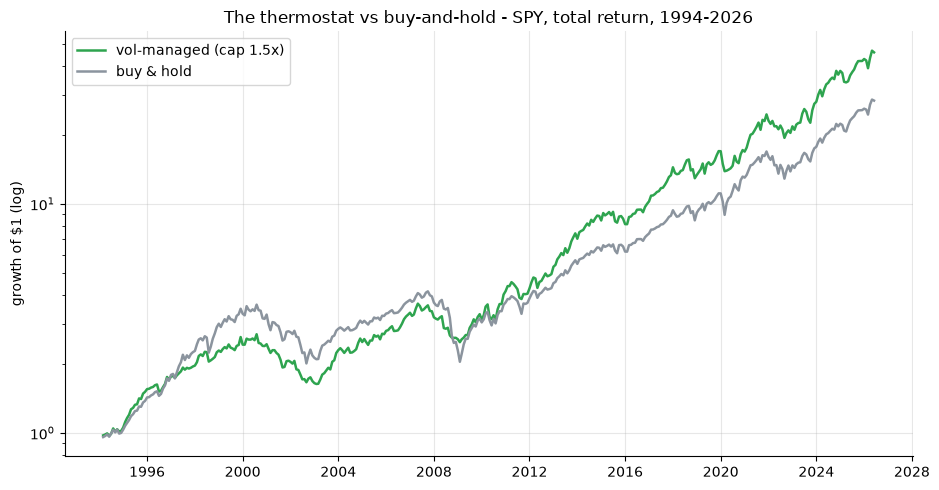

final: managed $46 vs buy&hold $28 per $1


In [2]:
if HAVE_REAL:
    ok = np.isfinite(W)
    sub = TBL.iloc[ok].copy(); sub['w'] = W[ok]
    nav_man = (1 + sub['rf'] + sub['w']*sub['exc']).cumprod()
    nav_bh  = (1 + sub['rf'] + sub['exc']).cumprod()
    x = sub.index.to_timestamp()
    fig, ax = plt.subplots()
    ax.plot(x, nav_man, c=GREEN, lw=1.8, label='vol-managed (cap 1.5x)')
    ax.plot(x, nav_bh, c=GREY, lw=1.8, label='buy & hold')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('The thermostat vs buy-and-hold - SPY, total return, 1994-2026')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final: managed ${nav_man.iloc[-1]:,.0f} vs buy&hold ${nav_bh.iloc[-1]:,.0f} per $1')
else:
    print('cache missing - frozen numbers:', R['sharpe_man'], 'vs', R['sharpe_bh'], 'Sharpe')

The managed line ends higher *and* rides a smoother path: Sharpe **0.72 vs 0.61** (both measured over T-bills). The extra return over what its market exposure explains — the **alpha** — is **+2.9%/yr**, and it just clears the desk's significance bar (details in the quants notebook).

**The thermostat itself.** Here's the exposure dial over time — watch it dive in 2008-09 and 2022, and note where it stood in February 2020.

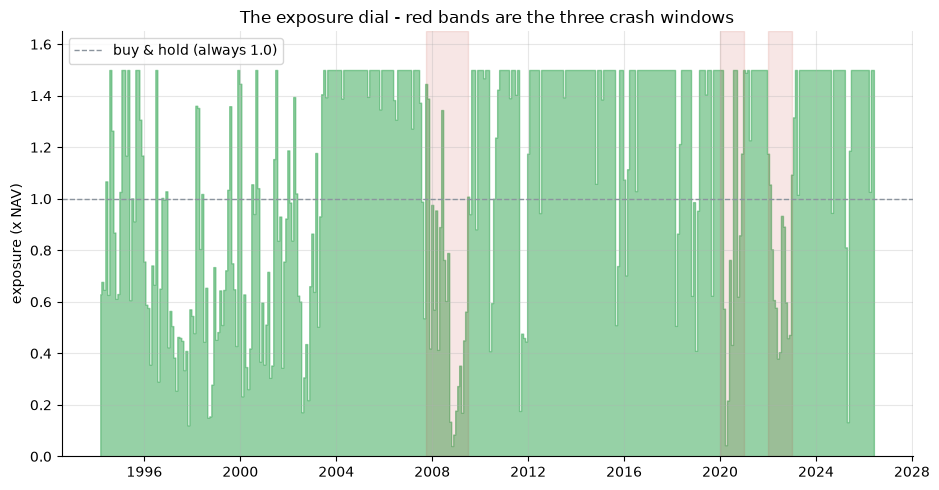

average weight 1.12 | at the 1.5x cap 49% of months | weight held during Feb 2020: 1.50


In [3]:
if HAVE_REAL:
    ok = np.isfinite(W)
    sub = TBL.iloc[ok]; x = sub.index.to_timestamp(); wv = W[ok]
    fig, ax = plt.subplots()
    ax.fill_between(x, wv, color=GREEN, alpha=.5, step='mid')
    ax.axhline(1.0, c=GREY, ls='--', lw=1, label='buy & hold (always 1.0)')
    for name, (a, b) in st.CRASH_WINDOWS.items():
        ax.axvspan(pd.Period(a,'M').to_timestamp(), pd.Period(b,'M').to_timestamp(how='end'),
                   color=RED, alpha=.12)
    ax.set_ylabel('exposure (x NAV)'); ax.set_ylim(0, 1.65)
    ax.set_title('The exposure dial - red bands are the three crash windows')
    ax.legend(); plt.tight_layout(); plt.show()
    feb20 = wv[sub.index == pd.Period('2020-02','M')]
    print(f'average weight {wv.mean():.2f} | at the 1.5x cap {100*(wv>=1.499).mean():.0f}% of months '
          f'| weight held during Feb 2020: {float(feb20[0]) if len(feb20) else float("nan"):.2f}')
else:
    print('cache missing - frozen: avg weight', R['avg_w'], '| capped', R['share_capped'], '% of months')

**Which crashes did it dodge?** Maximum loss inside each crash window, thermostat vs buy-and-hold.

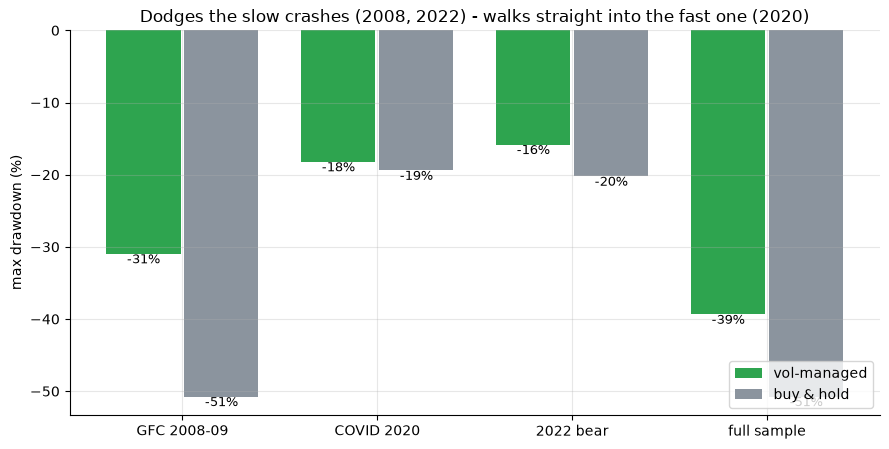

{'GFC 2008-09': (-31.0, -50.8), 'COVID 2020': (-18.2, -19.4), '2022 bear': (-15.8, -20.2), 'full sample': (-39.4, -50.8)}


In [4]:
if HAVE_REAL:
    ct = st.crash_table(TBL)
    rows = [(k, v['managed']*100, v['bh']*100) for k, v in ct.items()]
else:
    rows = [(a, b, c) for a, b, c in R['crashes']]
labs = [r[0] for r in rows]; man = [r[1] for r in rows]; bh = [r[2] for r in rows]
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x-.2, man, .38, color=GREEN, label='vol-managed')
ax.bar(x+.2, bh, .38, color=GREY, label='buy & hold')
for i,(m,b) in enumerate(zip(man,bh)):
    ax.annotate(f'{m:.0f}%',(i-.2,m),ha='center',va='top',fontsize=9)
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='top',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('max drawdown (%)')
ax.set_title('Dodges the slow crashes (2008, 2022) - walks straight into the fast one (2020)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print({l: (round(m,1), round(b,1)) for l,m,b in zip(labs,man,bh)})

> 🔬 **For the quants:** the 2008 dodge (−31% vs −51%) is the mechanism working as designed — vol had been elevated for months before Lehman, so exposure was already cut. February 2020 is its blind spot: January 2020 was one of the calmest months on the tape, the dial sat at the **1.5× cap**, and the fastest crash in history arrived inside the one-month rebalance window (−18.2% vs −19.4% — no help at all).

## 5 · The verdict

- **Signal — Mixed.** Real on US mega-caps: SPY alpha **+2.9%/yr** clears the bar at the wire and QQQ clears it comfortably; but international (EFA) and small-cap (IWM) versions don't come close. A real effect where vol clusters hardest, not a universal law.
- **Tradability — Fragile.** Costs from *trading* are negligible — but the strategy is levered ~half the time, and once a realistic margin spread is charged the alpha can no longer be certified (the Sharpe edge survives, the proof doesn't).
- **Does it dodge crashes? — Mixed.** Brilliant against storms that announce themselves (2008, 2022), useless against the ambush (2020). It's insurance with a one-month reaction time.

## 6 · Going further 🚪

- **Why does this work at all?** Because risk and reward are *disconnected* month to month: variance is forecastable, the equity premium isn't. The quants notebook builds synthetic worlds where that disconnect is dialed up and down — the strategy only earns alpha when the disconnect exists.
- **Faster thermostats** (daily vol targeting, intra-month triggers) fix some of the 2020 blind spot — at the price of far more trading. That's a different study.
- **Related desk studies:** [06-clockwork-vol](../../06-clockwork-vol/) (are there fixed-period vol *cycles*? No) and [130-vol-risk-premium](../../130-vol-risk-premium/) (the options-implied vol premium). This one is pure *scaling* — no options, no cycles.

*Think a household can fund 1.5× SPY at T-bill flat and keep the alpha? Show the margin statement — then we'll talk.*